In [1]:
import numpy as np
from PIL import Image  # pillow
import matplotlib.pyplot as plt

In [2]:
color_img = Image.open('/content/fruits.jpg')

In [ ]:
# Pillow Image객체를 이용해서 간단하게
# 출력할 수 있어요!
plt.imshow(color_img)
plt.show()

In [8]:
# Pillow Image객체를 이용해서
# 이미지의 pixel 정보를 추출할 수 있어요!
color_pixel = np.array(color_img)
# print(color_pixel)
# plt.imshow(color_pixel)
# plt.show()
print(color_pixel.shape)  # (426, 640, 3)

(426, 640, 3)


In [11]:
# 현재 color 이미지예요!
# gray scale image로 바꿔보아요!
# 각 pixel의 RGB값을 평균을 내서 그 값으로 RGB을 다시 설정
gray_pixel = color_pixel.copy()

for y in range(gray_pixel.shape[0]):
    for x in range(gray_pixel.shape[1]):
        gray_pixel[y,x] = int(np.mean(gray_pixel[y,x]))

# print(gray_pixel)
# plt.imshow(gray_pixel)
# plt.show()
print(gray_pixel.shape) # (426, 640, 3)

(426, 640, 3)


In [16]:
# 이런 이미지는 데이터량이 너무 많아요!
# 어떻게 하면 데이터량을 줄일 수 있을까요?
# 흑백이미지 같은 경우 3차원인데(height,width,1) 이렇게
# 표현이 가능
gray_3d_1channel = gray_pixel[:,:,0:1]
# print(gray_3d_1channel.shape) # (426, 640, 1)
# plt.imshow(gray_3d_1channel, cmap='gray')
# plt.show()

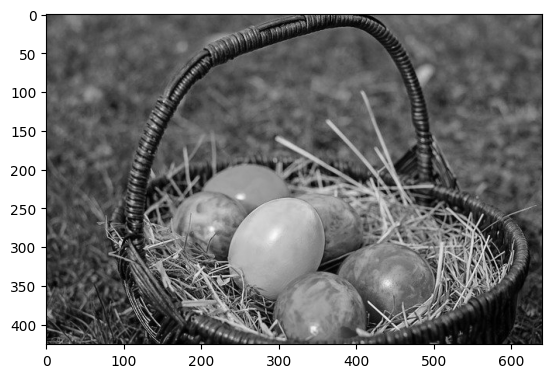

In [21]:
# 흑백이미지는 2차원으로 표현이 가능해요!
gray_2d = gray_pixel[:,:,0]
# print(gray_2d.shape) # (426, 640)
# print(gray_2d) # (426, 640)
plt.imshow(gray_2d, cmap='gray')
plt.show()

In [22]:
# 기존에 사용했던 MNIST Data Set에 대해서
# 다시한번 알아보아요!
# MNIST
# 일단 흑백이미지, 2차원으로 표현한 이미지 데이터
# 28 x 28 = 784의 pixel로 구성된 이미지
# 각 이미지는 숫자 0 ~ 9까지 중 하나의 숫자를 target으로
# 가지고 있어요!
# 이런 이미지 데이터가 많이 있어요..
# 전체 데이터 shape => 3차원이 되요!
# 하지만 우리가 사용하는 머신러닝은 입력데이터가
# 2차원이 되어야 해요! 즉, 데이터 1건이 1차원으로 표현되어야
# 해요!~ 정형데이터인경우는 이게 일반적이예요!
# 그래서 2차원인 이미지 데이터를 1차원으로 변경해야해요
# 공간정보가 날라가요

# 그래서 MNIST data는 2차원 데이터를 1차원으로 변경해서
# CSV 파일로 제공하고 있어요!

In [ ]:
# /content/drive/MyDrive/KDTHome/[data]/MNIST/train.csv

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1, l2

from sklearn.metrics import classification_report

In [48]:
# Raw Data Loading
df = pd.read_csv('/content/drive/MyDrive/KDTHome/[data]/MNIST/train.csv')
df.head()
df.shape  # (42000, 785)

(42000, 785)

In [49]:
# 데이터 전처리 및 feature engineering
# 결측치와 이상치가 없어요!

# 정규화를 진행해야 하는데 데이터를 분할하고 정규화를 진행!
x_data = df.drop('label', axis=1, inplace=False).values
t_data = df['label'].values.reshape(-1,1)

# t_data가 label을 의미하는데 각 class의 비율을 일단 먼저 알아보아요!
# print(np.unique(df['label'].values, return_counts=True))
# 데이터의 불균형문제는 없어요!

# train과 test를 분리
x_data_train, x_data_test, t_data_train, t_data_test = \
train_test_split(x_data,
                 t_data,
                 test_size=0.3,
                 stratify=t_data)

# 정규화를 진행
scaler = MinMaxScaler()
scaler.fit(x_data_train)
x_data_train_norm = scaler.transform(x_data_train)
x_data_test_norm = scaler.transform(x_data_test)

In [50]:
# Model 구현

model = Sequential()

# Input Layer의 shape의 값은
# 입력으로 들어오는 학습데이터 1건의 shape을 명시.
# 지금 현재는 이미지(28x28)의 데이터는 1차원으로 변경해서
# 입력으로 넣을꺼예요! 784개의 데이터를 가진 1차원 데이터가 입력으로
# 사용될 꺼예요!
# model.add(Input(shape=(784,)))
# model.add(Flatten())
model.add(Flatten(input_shape=(784,)))

# Hidden layer 추가 => DNN (Deep Neural Network)
# Batch Nomalization => 처음에 데이터에 대한 정규화 말고
# 학습 중간에 (레이어 안에서) 결과 데이터에 대해서 다시 정규화를 진행
# Layer안에서 Activation하기 전에 처리해 주면 되요!
# Keras에서는 이 기능을 layer로 만들어서 제공!
# activation작업도 Dense안에서 설정으로 처리하는게 아니라
# 별도의 Layer로 처리하도록 제공!
from tensorflow.keras.layers import Activation, BatchNormalization
from tensorflow.keras.layers import Dropout


# model.add(Dense(units=64,
#                 activation='relu'))
model.add(Dense(units=64))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(rate=0.5))

model.add(Dense(units=128,
                activation='relu'))
model.add(Dropout(rate=0.5))

output_layer = Dense(name='MyDenseLayer', # Layer의 논리적인 이름 설정
                     trainable=True,  # W의 값의 변경이 가능하도록 설정
                     units=10,
                     kernel_initializer="he_normal", # He's 초기화로 변경
                     kernel_regularizer=l2(l2=0.1),
                     activation='softmax')
# Dense Layer는 기본적으로 W의 초기화를 글로럿 초기화를 이용해요!
# (Xavier 초기화라고 하기도 해요!)
# 많이 사용되는 초기화 방법
# 1. glorot_normal : 글로럿 초기화방식(Xavier 초기화 방식)
# 2. he_normal : He's 초기화방식
# 3. recun_normal : 르쿤 초기화 방식
# 4. random_normal : 랜덤 초기화 방식(정규분포를 이용한 랜덤값을 사용)
# print(output_layer.get_config())

# 우리 Dense Layer는 기본적으로 규제를 사용하지 않고 있어요!
# 규제도 적용해서 모델의 최적화를 하면 좋아요!

model.add(output_layer)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MyDenseLayer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,106 (234.79 KB)

 Trainable params: 59,978 (234.29 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# 모델 학습
# 학습이 잘 안되는 경우가 종종 생겨요!
# 모델의 성능이 좋지 않은 대표적인 경우 중 하나는
# Overfitting 현상
# 이 Overfitting을 해결하려면
# 1. 학습데이터의 양을 늘리면 되요!
# 2. feature의 개수를 줄이면 되요!
# 3. Dropout 방식을 이용(Deep Learning에서 사용 가능)
# 4. 규제(Weight를 인위적으로 조절)
#    우리 모델의 복잡도를 낮추는 방법
#    L1 규제와 L2 규제가 있어요!

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es_callback = EarlyStopping(monitor='val_loss',
                            patience=5,
                            verbose=1)

cp_callback = ModelCheckpoint(filepath='/content/tmp_checkpoint.weights.h5',
                              save_weights_only=True,
                              save_best_only=True,
                              monitor='val_loss',
                              verbose=1)

history = model.fit(x_data_train_norm,
                    t_data_train,
                    epochs=100,
                    verbose=1,
                    callbacks=[es_callback, cp_callback],
                    validation_split=0.2)

In [51]:
# 모델 학습이 종료되었으니
# 평가를 진행
result = model.evaluate(x_data_test_norm,
                        t_data_test)
print(result)
# [0.20422561466693878, 0.9521428346633911]
# [4.288002967834473, 0.1701587289571762]  모델 학습하기 전!

394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1670 - loss: 4.2897
[4.288002967834473, 0.1701587289571762]


In [53]:
model.load_weights('/content/tmp_checkpoint.weights.h5')
result = model.evaluate(x_data_test_norm,
                        t_data_test)
print(result)
[0.1670343428850174, 0.9653968214988708]

 22/394 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9590 - loss: 0.1730 

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9653 - loss: 0.1646
[0.1670343428850174, 0.9653968214988708]


In [46]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y
